In [1]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments, scale_filter
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

from Kea.api.sim_data import SimulationData, SimulationType
from Kea.api.spectrum import Spectrum, SpectrumMethod

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as patches

import numpy as np

from scipy.signal import windows

import itertools

D = 3

N = 512
L = 2.*np.pi

grid_dims = [N for _ in range(D)]

phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi

dk = twopi/L

dx = L/N


In [2]:

data = SimulationData(SimulationType.H5_SEAN2, '/home/m/Documents/science_codes/Data/cmhd3d/', ['rho'], '01', phys_dims=phys_dims)


Reading file: iso-nu73-mhd3-01-uno-Xsp-rho.h5
Loaded rho


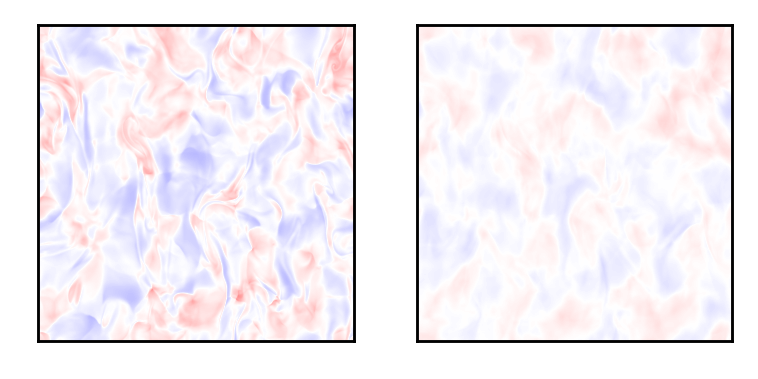

In [3]:

fig, ax = plt.subplots(1, 2, figsize=(3.5, 7.), dpi=256)
cmin, cmax = plotting.get_minmax(data.rho - np.nanmean(data.rho))
ax[0].imshow((data.rho - np.nanmean(data.rho))[:,:,128], origin='lower', cmap='bwr', vmin=cmin, vmax=cmax)
ax[1].imshow(np.nanmean(data.rho - np.nanmean(data.rho), axis=2), origin='lower', cmap='bwr', vmin=cmin, vmax=cmax)
for axx in ax:
    axx.set_xticks([])
    axx.set_yticks([])
#rect = patches.Rectangle((N_f//2-N//2, N_f//2-N//2), N, N, linewidth=1., edgecolor='black', linestyle=':', facecolor='none')
#ax[0].add_patch(rect)


In [4]:
spec = data.spectrum('rho', method='periodogram', demean=True)
_, _ = spec.integrate(int_type='omni')

Text(0.5, 0, 'Wavenumber, $k$')

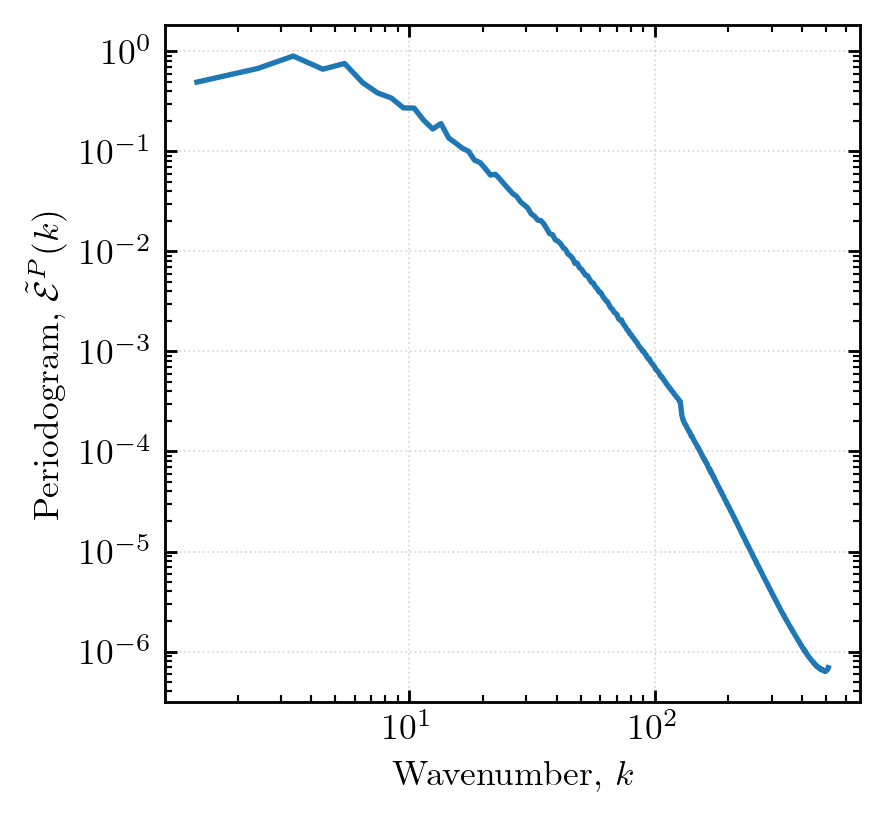

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.loglog(spec.omni_k, spec.omni_fek)

#ax.set_ylim((1e-5, 1e0))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'Periodogram, $\tilde{\mathcal{E}}^P(k)$')
ax.set_xlabel(r'Wavenumber, $k$')
